## Emotion Recognition from Speech

### 1.Install Libraries

In [1]:
!pip install librosa soundfile kaggle

### 2.Upload Kaggle File

In [2]:
from google.colab import files
files.upload()

Saving archive.zip to archive.zip


### 3.Setup Kaggle

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


### 4.Download Dataset

In [4]:
!kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio

Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0
100% 429M/429M [00:11<00:00, 38.8MB/s]



### 5.Extract Dataset

In [5]:
import zipfile

zip_path = "/content/ravdess-emotional-speech-audio.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/ravdess")

### 6.Import Libraries

In [6]:
import os
import librosa
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

### 7.Emotion Labels

In [7]:
emotion_dict = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful'
}

### 8.Data Augmentation Functions

In [8]:
def noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    data = data + noise_amp * np.random.normal(size=data.shape[0])
    return data

def pitch(data, sample_rate, pitch_factor=0.7):
    return librosa.effects.pitch_shift(
        data,
        sr=sample_rate,
        n_steps=pitch_factor
    )

### 9.Feature Extraction

In [9]:
def extract_features(file_path):

    data, sample_rate = librosa.load(
        file_path,
        duration=3,
        offset=0.5
    )

    result = []

    # Original Audio
    mfcc = np.mean(
        librosa.feature.mfcc(
            y=data,
            sr=sample_rate,
            n_mfcc=40
        ).T,
        axis=0
    )

    result.append(mfcc)

    # Noise Audio
    noise_data = noise(data)

    mfcc_noise = np.mean(
        librosa.feature.mfcc(
            y=noise_data,
            sr=sample_rate,
            n_mfcc=40
        ).T,
        axis=0
    )

    result.append(mfcc_noise)

    # Pitch Audio
    pitch_data = pitch(data, sample_rate)

    mfcc_pitch = np.mean(
        librosa.feature.mfcc(
            y=pitch_data,
            sr=sample_rate,
            n_mfcc=40
        ).T,
        axis=0
    )

    result.append(mfcc_pitch)

    return result

### 10.Load Dataset

In [10]:
X = []
y = []

dataset_path = "/content/ravdess"

for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if file.endswith(".wav"):

            file_path = os.path.join(root, file)

            emotion_code = file.split("-")[2]

            if emotion_code in emotion_dict:

                emotion = emotion_dict[emotion_code]

                features = extract_features(file_path)

                for feature in features:
                    X.append(feature)
                    y.append(emotion)

### 11.Convert Data

In [11]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(6336, 40)
(6336,)


### 12.Encode Labels

In [12]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

y_categorical = to_categorical(y_encoded)

### 13.Train Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_categorical,
    test_size=0.2,
    random_state=42
)

### 14.Reshape Data for LSTM

In [14]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)

X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

### 15.Build LSTM Model

In [15]:
model = Sequential()

model.add(
    LSTM(
        128,
        input_shape=(40,1),
        return_sequences=False
    )
)

model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(y_categorical.shape[1], activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### 16.Compile Model

In [16]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 17.Train Model

In [17]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.2731 - loss: 1.6818 - val_accuracy: 0.2942 - val_loss: 1.6224
Epoch 2/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.3548 - loss: 1.5526 - val_accuracy: 0.3226 - val_loss: 1.5553
Epoch 3/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.3907 - loss: 1.4757 - val_accuracy: 0.3872 - val_loss: 1.4305
Epoch 4/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.4165 - loss: 1.4057 - val_accuracy: 0.4314 - val_loss: 1.3921
Epoch 5/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.4331 - loss: 1.3681 - val_accuracy: 0.4259 - val_loss: 1.3261
Epoch 6/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 9s 56ms/step - accuracy: 0.4461 - loss: 1.3290 - val_accuracy: 0.4614 - val_loss: 1.2755
Epoch 7/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 18s 112ms/step - accuracy: 0.4781 - loss: 1.2689 - val_accuracy: 0.4708 - val_loss: 1.2689
Epoch 8/50
159/159 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.4897 - loss: 1.2422 - val

### 18.Evaluate Model

In [18]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)

40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.8257 - loss: 0.5871
Test Accuracy: 0.8257097601890564


### 19.Predict Emotion

In [19]:
predictions = model.predict(X_test)

predicted_label = np.argmax(predictions[0])

predicted_emotion = label_encoder.inverse_transform(
    [predicted_label]
)

print("Predicted Emotion:", predicted_emotion[0])

40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Predicted Emotion: fearful


### 20.Save Model

In [20]:
model.save("emotion_recognition_model.h5")

### 21.Accuracy Graph

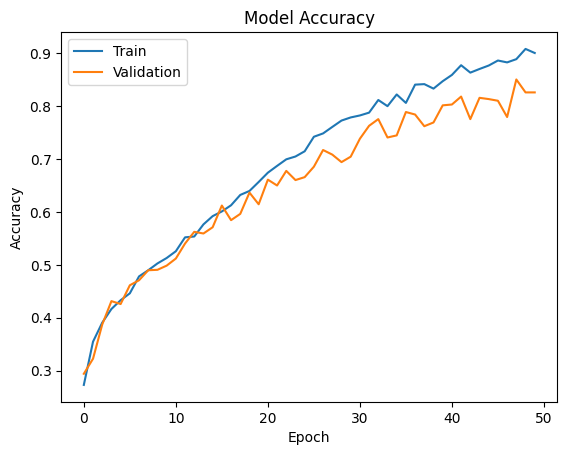

In [21]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()